In [1]:
import pandas as pd
import numpy as np
from bromo.evaluations.tka import plot_tka_learning_curves


### 1. Learning curve for human-astral

In [2]:
seeds = ['seed0','seed10','seed20','seed30','seed40']
sample_sizes = ['0.01','0.025','0.05','0.1','0.25','0.5','0.6','0.75','0.9','0.95','fulldata']
sample_dirs = ['sample_0.01','sample_0.025','sample_0.05','sample_0.1','sample_0.25','sample_0.5','sample_0.6','sample_0.75','sample_0.9','sample_0.95','sample_full']
tka_overall_results_bromo = []
tka_overall_results_xgboost = []
protein_groups_overall_results = []
peptide_pairs_overall_results = []
for seed in seeds:
    protein_groups = []
    peptide_pairs = []
    tka_k3_bromo = []
    tka_k3_xgboost = []
    for idx,sample in enumerate(sample_sizes):
        if sample=='fulldata':
            train = pd.read_csv('../../Datasets/pretraining/human-astral/train.tsv',sep='\t')
            tka_results = pd.read_csv('../../Datasets/learning_curve/human-astral/sample_full/tka_results.csv')

        else:
            train = pd.read_csv(f'../../Datasets/learning_curve/human-astral/{seed}/{sample_dirs[idx]}/sampled_proteins_{sample}.tsv',sep='\t')
            tka_results = pd.read_csv(f'../../Datasets/learning_curve/human-astral/{seed}/{sample_dirs[idx]}/tka_results.csv')
        
        protein_groups.append(train['protein'].nunique())
        peptide_pairs.append(train['peptide_pair'].nunique())
        del train
        tka_k3_bromo += [np.mean([float(i) for i in tka_results['Bromo'].str.split(',').str[2]])]
        tka_k3_xgboost += [np.mean([float(i) for i in tka_results['XGBoost'].str.split(',').str[2]])]

    tka_overall_results_bromo += [tka_k3_bromo]
    tka_overall_results_xgboost += [tka_k3_xgboost]
    protein_groups_overall_results += [protein_groups]
    peptide_pairs_overall_results += [peptide_pairs]


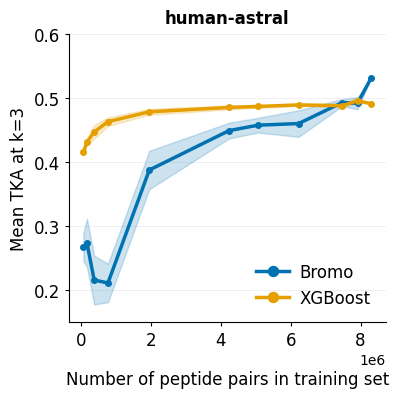

In [3]:
plot_tka_learning_curves(
    x=np.round(np.mean(peptide_pairs_overall_results,axis=0)),
    methods={
        "Bromo": np.array(tka_overall_results_bromo),
        "XGBoost": np.array(tka_overall_results_xgboost),
    },
    secondary_x_labels=None,
    title="human-astral",
    save_path="./fig5_human_astral.pdf",
)

### 2. Learning curve for human-pan

In [2]:
seeds = ['seed0','seed10','seed20','seed30','seed40']
sample_sizes = ['0.01','0.025','0.05','0.1','0.25','0.5','0.6','0.75','0.9','0.95','fulldata']
sample_dirs = ['sample_0.01','sample_0.025','sample_0.05','sample_0.1','sample_0.25','sample_0.5','sample_0.6','sample_0.75','sample_0.9','sample_0.95','sample_full']
tka_overall_results_bromo = []
tka_overall_results_xgboost = []
protein_groups_overall_results = []
peptide_pairs_overall_results = []
for seed in seeds:
    protein_groups = []
    peptide_pairs = []
    tka_k3_bromo = []
    tka_k3_xgboost = []
    for idx,sample in enumerate(sample_sizes):
        if sample=='fulldata':
            train = pd.read_csv('../../Datasets/finetuning/human-pan/train.tsv',sep='\t')
            tka_results = pd.read_csv('../../Datasets/learning_curve/human-pan/sample_full/tka_results.csv')

        else:
            train = pd.read_csv(f'../../Datasets/learning_curve/human-pan/{seed}/{sample_dirs[idx]}/sampled_proteins_{sample}.tsv',sep='\t')
            tka_results = pd.read_csv(f'../../Datasets/learning_curve/human-pan/{seed}/{sample_dirs[idx]}/tka_results.csv')
        
        protein_groups.append(train['protein'].nunique())
        peptide_pairs.append(train['peptide_pair'].nunique())
        del train
        tka_k3_bromo += [np.mean([float(i) for i in tka_results['Bromo'].str.split(',').str[2]])]
        tka_k3_xgboost += [np.mean([float(i) for i in tka_results['XGBoost'].str.split(',').str[2]])]

    tka_overall_results_bromo += [tka_k3_bromo]
    tka_overall_results_xgboost += [tka_k3_xgboost]
    protein_groups_overall_results += [protein_groups]
    peptide_pairs_overall_results += [peptide_pairs]


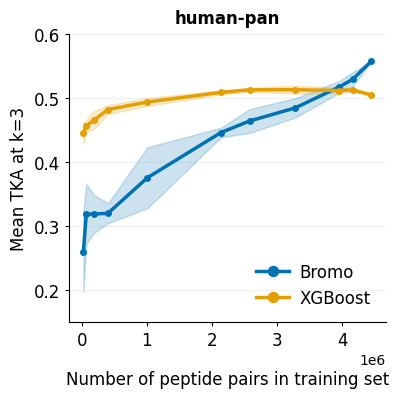

In [3]:
plot_tka_learning_curves(
    x=np.round(np.mean(peptide_pairs_overall_results,axis=0)),
    methods={
        "Bromo": np.array(tka_overall_results_bromo),
        "XGBoost": np.array(tka_overall_results_xgboost),
    },
    secondary_x_labels=None,
    title="human-pan",
    save_path="./fig5_human_pan.pdf",
)